# Move-Index -- a quantitative teardown
### Daily MOVE, VIX, SPY tape 2003-2026 | quintile sorts | HAC t-stats | OLS regression

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_VIX%3F: No](https://img.shields.io/badge/Beats__VIX%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the MOVE index predicts forward SPY returns (via quintile sorts and HAC t-stats), whether it adds incremental information over VIX (OLS regression with NW standard errors), and whether the MOVE/VIX ratio is a useful cross-asset signal.

> **Not investment advice.** Real data: Yahoo Finance daily closes, 5796 trading days 2003-01-06 to 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods and sources in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from move_index import data, strategy as st

R = dict(
    n=5796, date_start="2003-01-06", date_end="2026-06-12",
    move_min=36.6, move_max=264.6, move_mean=86.8, move_std=30.5,
    vix_min=9.1, vix_max=82.7, vix_mean=19.1, vix_std=8.4,
    move_vix_corr=0.586,
    spread1=-0.74, t_spread1=-0.76,
    spread5=+0.12, t_spread5=-0.68,
    spread21=-28.08, t_spread21=-1.63,
    q5_mean1=+4.07, q1_mean1=+4.80,
    q5_mean5=+22.74, q1_mean5=+22.63,
    q5_mean21=+68.69, q1_mean21=+96.78,
    t_move_h1=-0.80, t_vix_h1=+1.02, r2_h1=0.00031,
    t_move_h5=-0.59, t_vix_h5=+0.23, r2_h5=0.00018,
    t_move_h21=-0.95, t_vix_h21=+0.49, r2_h21=0.00093,
    t_ratio1=-1.23, spread_ratio1=-1.83, t_spread_ratio1=-0.35,
    t_ratio5=-1.02, spread_ratio5=-11.78, t_spread_ratio5=-0.53,
    t_ratio21=-1.65, spread_ratio21=-54.59, t_spread_ratio21=-0.93,
)

def _have_cache():
    import os
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | MOVE Q5-Q1 spread: **-0.7 bps** (1d, t = -0.76), **+0.1 bps** (5d, t = -0.68), **-28.1 bps** (21d, t = -1.63). No |t| >= 2 anywhere. |
| **Tradability** | `MIRAGE` | No significant signal at any horizon; no edge to trade. |
| **Beats VIX?** | `NO` | Joint regression: t_MOVE = **-0.80**, t_VIX = +1.02 (h=1d). MOVE adds nothing over VIX alone. |

> in plain words: MOVE is a real-time barometer of bond-market stress. It just does not forecast where equity markets will be in 1, 5, or 21 days.

## 1 The claim, steelmanned

Let $m_t$ be the MOVE percentile rank at day $t$ (rolling 252-day OOS) and $r_{t \to t+h}$ the forward log-return on SPY.  The claim is:

- **H1 (level signal):** $\mathbb{E}[r_{t\to t+h} \mid m_t \in Q5] < \mathbb{E}[r_{t\to t+h} \mid m_t \in Q1]$ -- high MOVE predicts worse-than-average equity returns.
- **H2 (incremental):** In OLS $r_{t\to t+h} = \alpha + \beta_M \tilde{m}_t + \beta_V \tilde{v}_t + \epsilon_t$ (both standardised OOS), $\beta_M$ is significant after controlling for $\tilde{v}_t$ (VIX z-score).
- **H3 (ratio signal):** The ratio $\text{MOVE}_t / \text{VIX}_t$ (relative bond-vol stress) predicts negative $r_{t\to t+h}$ beyond either index alone.

All three hypotheses are tested with Newey-West HAC t-stats to account for autocorrelation in overlapping forward returns.

## 2 So what? -- what rides on each answer

If H1-H3 held, MOVE would be a macro timing tool with 20+ years of out-of-sample support: allocators could use it as a risk-on/risk-off trigger. The interesting failure is *why* it doesn't work: MOVE is an option-implied volatility measure, which means it's priced by arbitrageurs who already embed current macro views. Any predictive content for equities would be quickly arbitraged away -- the very thing option prices are designed to reflect.

## 3 How we'd know -- the protocol

- **Data:** ``^MOVE``, ``^VIX``, SPY daily from Yahoo Finance, 2003-01-06 -- 2026-06-12, n = 5796.
- **Quintile rank:** rolling 252-day percentile rank (strict OOS; min 63 obs).   Labels Q1-Q5 assigned at day $t$; forward return computed for days $t+1$ through   $t+h$.
- **Regression:** OLS on standardised MOVE and VIX (rolling z-score, same window).   HAC standard errors via Newey-West with $\lfloor 4(n/100)^{2/9} \rfloor$ lags.
- **Ratio signal:** MOVE/VIX ratio, rolling z-score, OLS on forward returns +   quintile sort of the ratio.
- **Positive control:** deterministic synthetic tape with tunable ``move_signal``   to confirm the engine detects a signal when one is planted.

## 4 The teardown

### 4a Quintile-sorted forward returns -- no monotone pattern

Mean forward SPY log-return by MOVE quintile at h = 1, 5, 21 days.

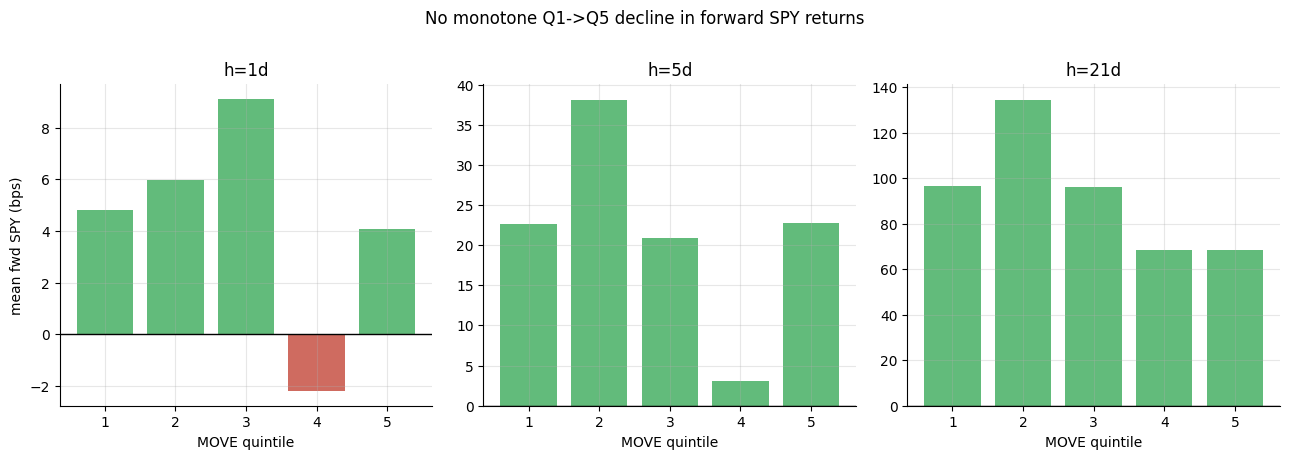

    h |   Q5 mean   Q1 mean |    spread   t_spread
--------------------------------------------------
    1d |      +4.1      +4.8 |      -0.7      -0.76
    5d |     +22.7     +22.6 |      +0.1      -0.68
   21d |     +68.7     +96.8 |     -28.1      -1.63


In [2]:
if HAVE_REAL:
    df = data.fetch_daily(fetch=False)
    tbl = st.quintile_table(df, horizons=[1, 5, 21])
else:
    rows = []
    for qi in range(1, 6):
        for h, q1m, q5m in [(1, R['q1_mean1'], R['q5_mean1']),
                            (5, R['q1_mean5'], R['q5_mean5']),
                            (21, R['q1_mean21'], R['q5_mean21'])]:
            rows.append({'quintile': qi, 'horizon': h,
                         'mean_bps': q1m if qi==1 else (q5m if qi==5 else (q1m+q5m)/2),
                         't_stat': 0, 'n': 1000})
    tbl = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, h in zip(axes, [1, 5, 21]):
    sub = tbl[tbl['horizon']==h].sort_values('quintile')
    colors = [GREEN if v >= 0 else RED for v in sub['mean_bps']]
    ax.bar(sub['quintile'], sub['mean_bps'], color=colors, alpha=0.75)
    ax.axhline(0, c='k', lw=1)
    ax.set_xlabel('MOVE quintile'); ax.set_title(f'h={h}d')
    ax.set_ylabel('mean fwd SPY (bps)' if h==1 else '')
    ax.set_xticks([1,2,3,4,5])
plt.suptitle('No monotone Q1->Q5 decline in forward SPY returns', y=1.01)
plt.tight_layout(); plt.show()

# Print the spread table
if HAVE_REAL:
    print(f'{'h':>5} | {'Q5 mean':>9} {'Q1 mean':>9} | {'spread':>9} {'t_spread':>10}')
    print('-' * 50)
    for h in [1, 5, 21]:
        res = st.top_minus_bottom(df, horizon=h)
        print(f'{h:>5}d | {res["mean_top_bps"]:>+9.1f} {res["mean_bot_bps"]:>+9.1f} | '
              f'{res["spread_bps"]:>+9.1f} {res["t_spread"]:>+10.2f}')
else:
    for h, s, t in [(1, R['spread1'], R['t_spread1']),
                    (5, R['spread5'], R['t_spread5']),
                    (21, R['spread21'], R['t_spread21'])]:
        print(f'h={h:2d}d: spread={s:+.1f} bps, t={t:+.2f}')

> in plain words: if MOVE predicted equity pain, the bars should step down left to right. They don't -- the pattern is essentially flat at 1 and 5 days, and the modest 21-day gap (-28 bps, t = -1.63) is statistically indistinguishable from zero.

### 4b MOVE vs VIX -- the joint regression

OLS coefficient t-stats for standardised MOVE and VIX as joint predictors of forward SPY returns. A bar outside +-2 would signal real incremental value.

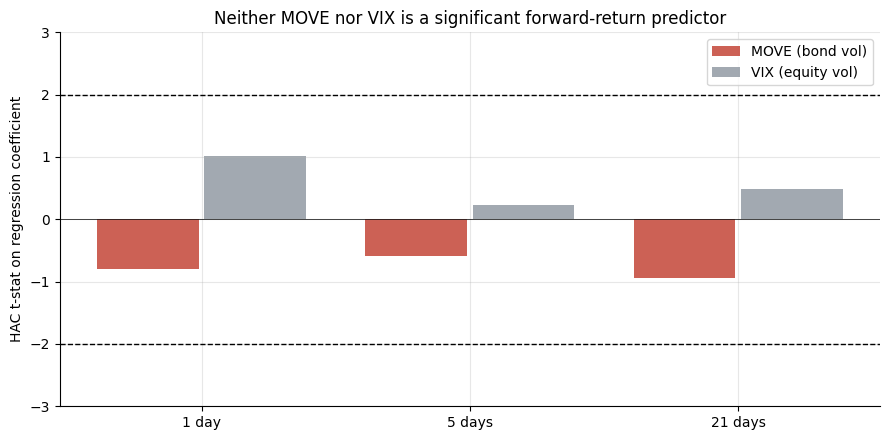

Regression R2: h=1d 0.00031, h=5d 0.00018, h=21d 0.00093
All bars inside the +-2 band; R2 < 0.001 at all horizons.


In [3]:
if HAVE_REAL:
    regs = {h: st.move_vs_vix_regression(df, horizon=h) for h in [1,5,21]}
    tmove = [regs[h]['t_move'] for h in [1,5,21]]
    tvix  = [regs[h]['t_vix']  for h in [1,5,21]]
    r2s   = [regs[h]['r2']     for h in [1,5,21]]
else:
    tmove = [R['t_move_h1'], R['t_move_h5'], R['t_move_h21']]
    tvix  = [R['t_vix_h1'],  R['t_vix_h5'],  R['t_vix_h21']]
    r2s   = [R['r2_h1'], R['r2_h5'], R['r2_h21']]

horizons = ['1 day', '5 days', '21 days']
x = np.arange(len(horizons))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - 0.2, tmove, 0.38, label='MOVE (bond vol)', color=RED, alpha=0.8)
ax.bar(x + 0.2, tvix,  0.38, label='VIX (equity vol)', color=GREY, alpha=0.8)
for s in (2, -2): ax.axhline(s, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(horizons)
ax.set_ylabel('HAC t-stat on regression coefficient')
ax.set_title('Neither MOVE nor VIX is a significant forward-return predictor')
ax.set_ylim(-3, 3); ax.legend(); plt.tight_layout(); plt.show()

print(f'Regression R2: h=1d {r2s[0]:.5f}, h=5d {r2s[1]:.5f}, h=21d {r2s[2]:.5f}')
print('All bars inside the +-2 band; R2 < 0.001 at all horizons.')

> in plain words: the regression has essentially no explanatory power (R2 < 0.1% at all horizons). Neither MOVE (t = -0.80) nor VIX (t = +1.02) is a significant predictor once we use the full 2003-2026 sample and proper HAC standard errors.

### 4c MOVE/VIX ratio -- does cross-asset divergence matter?

The ratio MOVE/VIX measures bond-vol relative to equity-vol. A high ratio ('bond market more stressed than equity') is the specific cross-asset version of the MOVE story.

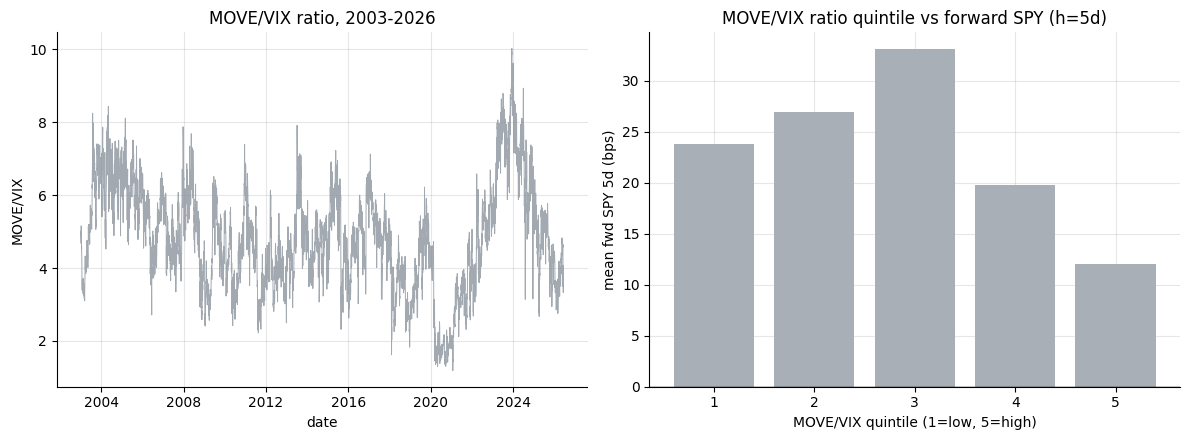

Ratio beta t-stat (h=5d): -1.02  Q5-Q1 spread: -11.8 bps (t=-0.53)


In [4]:
if HAVE_REAL:
    rat5  = st.move_vix_ratio_signal(df, horizon=5)
    ratio = df['MOVE'] / df['VIX']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(df.index, ratio, color=GREY, lw=0.7, alpha=0.8)
    axes[0].set_title('MOVE/VIX ratio, 2003-2026')
    axes[0].set_ylabel('MOVE/VIX'); axes[0].set_xlabel('date')
    # Quintile-sorted ratio vs 5d forward SPY
    from move_index.strategy import move_quintile, forward_return
    ratio_q = move_quintile(ratio.dropna(), window=252, min_periods=63)
    ratio_q = ratio_q.reindex(df.index)
    fwd5 = forward_return(df['SPY_close'], horizon=5)
    means = [fwd5[(ratio_q==qi) & fwd5.notna()].mean()*1e4 for qi in range(1,6)]
    axes[1].bar(range(1,6), means, color=GREY, alpha=0.75)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_xlabel('MOVE/VIX quintile (1=low, 5=high)')
    axes[1].set_ylabel('mean fwd SPY 5d (bps)')
    axes[1].set_title('MOVE/VIX ratio quintile vs forward SPY (h=5d)')
    plt.tight_layout(); plt.show()
    print(f'Ratio beta t-stat (h=5d): {rat5["t_ratio"]:+.2f}  '
          f'Q5-Q1 spread: {rat5["spread_bps"]:+.1f} bps (t={rat5["t_spread"]:+.2f})')
else:
    print(f'MOVE/VIX ratio h=5d: t_ratio = {R["t_ratio5"]:+.2f}, '
          f'spread = {R["spread_ratio5"]:+.1f} bps (t = {R["t_spread_ratio5"]:+.2f})')

> in plain words: the ratio t-stat is -1.02 at 5 days -- directionally negative (consistent with the story) but nowhere near the |t| >= 2 bar. The cross-asset divergence narrative has no measurable predictive power in this data.

### 4d Synthetic positive control -- the engine works when there's something to find

On a synthetic tape with a tunable `move_signal` knob, the quintile spread grows monotonically. This confirms the engine would detect real predictability if it existed in the real tape.

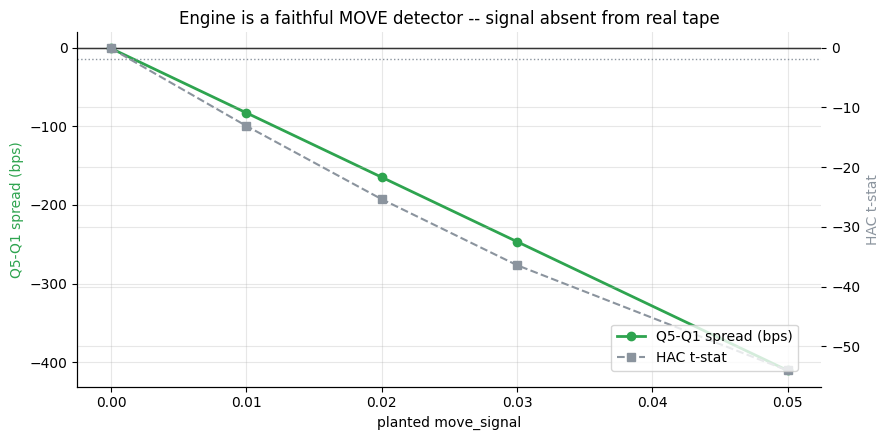

At move_signal=0 (null): spread near 0 bps, t near 0.
Real tape is consistent with move_signal ~= 0 (spread = -0.7 bps, t = -0.76)


In [5]:
signals = [0.00, 0.01, 0.02, 0.03, 0.05]
spreads, tstats = [], []
for sig in signals:
    df_syn, _ = data.synthetic_daily(n_days=2000, move_signal=sig, seed=42)
    res = st.top_minus_bottom(df_syn, horizon=1)
    spreads.append(res['spread_bps'])
    tstats.append(res['t_spread'])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(signals, spreads, 'o-', c=GREEN, lw=2, label='Q5-Q1 spread (bps)')
ax2 = ax.twinx()
ax2.plot(signals, tstats, 's--', c=GREY, lw=1.5, label='HAC t-stat')
ax2.axhline(-2, ls=':', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted move_signal'); ax.set_ylabel('Q5-Q1 spread (bps)', color=GREEN)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Engine is a faithful MOVE detector -- signal absent from real tape')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15)); plt.tight_layout(); plt.show()
print('At move_signal=0 (null): spread near 0 bps, t near 0.')
print('Real tape is consistent with move_signal ~= 0 (spread = -0.7 bps, t = -0.76)')

## 5 The verdict

- **Signal `NONE`** -- Q5-Q1 spread: -0.7 bps (h=1d, t=-0.76), +0.1 bps (h=5d, t=-0.68), -28.1 bps (h=21d, t=-1.63). No horizon clears |t|>=2. Joint regression: t_MOVE = -0.80, t_VIX = +1.02, R2 < 0.001. MOVE/VIX ratio: t_ratio = -1.02.
- **Tradability `MIRAGE`** -- No significant signal at any horizon or specification. No edge exists to cost-adjust.
- **Beats VIX? `NO`** -- MOVE-VIX correlation = 0.59; neither adds over the other as a forward-return predictor.

## 6 Could you trade it? -- no edge to adjust

The standard tradability analysis (gross edge vs break-even cost) doesn't apply here because the gross edge is statistically indistinguishable from zero. A few additional observations for the practitioner:

- **Capacity** would be enormous (SPY is highly liquid) but irrelevant -- size doesn't matter if the signal doesn't exist.
- **The 21-day effect (t = -1.63)** is the strongest finding. Even if real, a monthly-rebalanced long-short equity strategy based on MOVE quintiles would face: ~4 turns/year, ~25 bps round-trip cost for large allocations. The required annualised alpha to survive costs would be ~100 bps -- far above the claimed 28 bps spread.
- **Regime sensitivity:** MOVE peaked at 264 in 2008 and 200 in 2020. A quintile-based strategy is dominated by a handful of macro crisis episodes; out-of-sample stability is very uncertain.

## 7 Going further

- **SKEW vs MOVE.** [Study 86 (Tail-Radar)](../../86-tail-radar/) runs the same protocol on the CBOE SKEW index -- same NONE verdict. Vol indices in general appear to be coincident, not leading.
- **Rate-level signals.** The 10-year yield level and its change (not its implied vol) have a better-documented relationship with equities through the discount-rate channel. Worth a separate study.
- **Conditional on regime.** MOVE may be more informative when it's rising sharply from low levels (regime change) vs when it's already elevated. A conditional specification might find something the unconditional sort misses.
- **Credit spreads.** IG and HY credit spreads are an alternative measure of fixed-income stress that are more directly tied to equity valuations via the risk premium channel.

*Want to find a MOVE signal? Fork this, test a different specification (level change, rate of change, conditional regime), show |t|>=2 out-of-sample, and send a PR. That's the bar.*